# **TP7 - Corresponding Analysis (CA)**

<b>Exploratory Data Analysis & Unsuperivsed Learning </b><br>
**Lecturer: Dr. HAS Sothea** <br> 
**Ms. UANN Sreyvi**

Student: PHORN Sreypov

-------

**Objective**: Qualitative columns are often ignored in predictive models or analysis. It is important to notice that qualitative variables are as important as the quantitative ones when it comes to building predictive models or analyzing their connection within the dataset. In this TP, we will focus on identifying the associations between two qualitative variables.

---------

> **The `Jupyter Notebook` for this TP can be downloaded here: [TP7_CA.ipynb](https://hassothea.github.io/EDA_ITC/TPs/TP7_CA.ipynb)**.

-------

## 1. Data loading and Preprocessing

`Titanic` dataset contains information on the passengers aboard the RMS Titanic, which sank in 1912. It includes details like age, gender, class, and survival status.

**A.** Import the `Titanic` dataset from kaggle using: [Titanic dataset](https://www.kaggle.com/datasets/surendhan/titanic-dataset).

- How many quantitative and qualitative variables are there in this dataset?
- Convert each column into its correct data type.

In [ ]:
import kagglehub

# path = kagglehub.dataset_download("surendhan/titanic-dataset")
# print("Dataset path:", path)


Dataset path: C:\Users\Asus Zenbook\.cache\kagglehub\datasets\surendhan\titanic-dataset\versions\1


In [15]:
path = r'C:\Users\Asus Zenbook\.cache\kagglehub\datasets\surendhan\titanic-dataset\versions\1'


In [16]:
# Import data
import pandas as pd
df= pd.read_csv(path + "/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [38]:
# To do
# - How many quantitative and qualitative variables are there in this dataset?
# - Convert each column into its correct data type.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [39]:
df["Ticket"]= pd.to_numeric(df["Ticket"], errors="coerce")

In [40]:
df.sample(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
247,1139,0,2,"Drew, Mr. James Vivian",male,42.0,1,1,28220.0,32.5,NaN,S


In [41]:
df['Parch'].unique()

array([0, 1, 3, 2, 4, 6, 5, 9], dtype=int64)

In [42]:
df["Parch"].unique()# quan -dist 

array([0, 1, 3, 2, 4, 6, 5, 9], dtype=int64)

In [43]:
df['Pclass'].unique() 

array([3, 2, 1], dtype=int64)

In [44]:
df['SibSp'].unique() # quan-dist 

array([0, 1, 2, 3, 4, 5, 8], dtype=int64)

In [45]:
df['Survived'].unique() 
# Survived  418 non-null    int64 
# Pclass    418 non-null    int64 

df['Survived']= df['Survived'].astype("category")
df['Pclass'] = df['Pclass'].astype("category")

df[['Survived', 'Pclass']].dtypes

Survived    category
Pclass      category
dtype: object

In [46]:
df['Cabin'].unique() 

array([nan, 'B45', 'E31', 'B57 B59 B63 B66', 'B36', 'A21', 'C78', 'D34',
       'D19', 'A9', 'D15', 'C31', 'C23 C25 C27', 'F G63', 'B61', 'C53',
       'D43', 'C130', 'C132', 'C101', 'C55 C57', 'B71', 'C46', 'C116',
       'F', 'A29', 'G6', 'C6', 'C28', 'C51', 'E46', 'C54', 'C97', 'D22',
       'B10', 'F4', 'E45', 'E52', 'D30', 'B58 B60', 'E34', 'C62 C64',
       'A11', 'B11', 'C80', 'F33', 'C85', 'D37', 'C86', 'D21', 'C89',
       'F E46', 'A34', 'D', 'B26', 'C22 C26', 'B69', 'C32', 'B78',
       'F E57', 'F2', 'A18', 'C106', 'B51 B53 B55', 'D10 D12', 'E60',
       'E50', 'E39 E41', 'B52 B54 B56', 'C39', 'B24', 'D28', 'B41', 'C7',
       'D40', 'D38', 'C105'], dtype=object)

In [47]:
df['Ticket'].dtype 

dtype('float64')

In [48]:
qualitative_cols = ["Survived","Pclass", "Name", "Sex", "Cabin", "Embarked"]
df[qualitative_cols].head()


,Survived,Pclass,Name,Sex,Cabin,Embarked
0,0,3,"Kelly, Mr. James",male,NaN,Q
1,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,NaN,S
2,0,2,"Myles, Mr. Thomas Francis",male,NaN,Q
3,0,3,"Wirz, Mr. Albert",male,NaN,S
4,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,NaN,S


In [49]:
#  Name Cabin PassengerId  
# Embarket: QUEENSTOWN,IRELAND , SOUTHAMPTON,ENGLAND, CHERBOURG,FRANCE 

In [50]:
quantitative_cols = [col for col in df.columns if col not in qualitative_cols and col != "PassengerId"]
df[quantitative_cols].head()


,Age,SibSp,Parch,Ticket,Fare
0,34.5,0,0,330911.0,7.8292
1,47.0,1,0,363272.0,7.0000
2,62.0,0,0,240276.0,9.6875
3,27.0,0,0,315154.0,8.6625
4,22.0,1,1,3101298.0,12.2875


**B.** Are there any missing values? If so,

- Study the impact of missing value removal on the quantitative variables.
- Study the impact of missing value removal on the qualitative variables.
- Conclude the dynamic of the missing values and handle them.
- Remove redundant observations if there is any.

In [ ]:
# 1. Missing values summary
missing = df.isna().sum()

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": (missing / len(df)) * 100
}).sort_values("Missing %", ascending=False)

missing_summary


,Missing Count,Missing %
Cabin,327,78.229665
Age,86,20.574163
Fare,1,0.239234
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000


- Cabin: many missing values 327
- Age : 86 missing values 
- Ticket : 122 
- Fare : 1

In [ ]:
# missing_cols = ["Age", "Ticket","Cabin" "Fare"] # [86, 122,,327,0]

In [ ]:
# 2. Impact of missing value removal on quantitative variables

# before removal
df[quantitative_cols].describe().style.background_gradient()


,Age,SibSp,Parch,Fare
count,332.000000,418.000000,418.000000,417.000000
mean,30.272590,0.447368,0.392344,35.627188
std,14.181209,0.896760,0.981429,55.907576
min,0.170000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,0.000000,7.895800
50%,27.000000,0.000000,0.000000,14.454200
75%,39.000000,1.000000,0.000000,31.500000
max,76.000000,8.000000,9.000000,512.329200


In [ ]:
# after removal 
df_quant_drop = df.dropna(subset=quantitative_cols)
df_quant_drop[quantitative_cols].describe().style.background_gradient()

,Age,SibSp,Parch,Fare
count,331.000000,331.000000,331.000000,331.000000
mean,30.181269,0.483384,0.398792,40.982087
std,14.104573,0.875004,0.811582,61.228558
min,0.170000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,0.000000,8.050000
50%,27.000000,0.000000,0.000000,16.000000
75%,39.000000,1.000000,1.000000,40.633350
max,76.000000,8.000000,6.000000,512.329200


Mean and standard deviation of **Fare** change

In [128]:
print("Original size:", df.shape[0])
print("After dropping quantitative NA:", df_quant_drop.shape[0])


Original size: 418
After dropping quantitative NA: 331


In [129]:
# 3 Impact of missing value removal on qualitative variables

# frequency before 
df["Embarked"].value_counts(dropna=False)


Embarked
S    270
C    102
Q     46
Name: count, dtype: int64

In [ ]:
# after removed
df_qual_drop = df.dropna(subset=qualitative_cols)
df_qual_drop["Embarked"].value_counts()


Embarked
C    49
S    41
Q     1
Name: count, dtype: int64

In [132]:
print("Original size:", df.shape[0])
print("After dropping qualitative NA:", df_qual_drop.shape[0])


Original size: 418
After dropping qualitative NA: 91


Removing missing Cabin removes most of the dataset. 
Category proportions are distorted. 
Dropping qualitative missing values is not acceptable.

In [ ]:
# 4 Dynamic of missing values 
# - Age : Quan type MAR 
# - Cabin: Qual type MNAR 
# - Emnarked: Qual type MCAR 

In [ ]:
# 5 Handling missing values (correct strategy)  

- For Quantitative var 
    Age : I use median imputation 

In [133]:
df["Age"] = df["Age"].fillna(df["Age"].median())


- For quanlitative var: mode

    - The mode is the most frequent category because it can minimizes expected classification error

In [ ]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [ ]:
# Cabin : transform 
df["HasCabin"] = df["Cabin"].notna()
df = df.drop(columns=["Cabin"])

In [137]:
# 6. remove redundancy 
df.duplicated().sum()
df = df.drop_duplicates()


In [139]:
print(df.isna().sum())
print(df.dtypes)
df.shape


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
HasCabin       0
dtype: int64
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
HasCabin          bool
dtype: object


(418, 12)

## 2. $\chi^2$-test and CA

The chi-square test is a statistical method used to determine if there is a significant association between two categorical variables. It tests the following hypotheses:
$$\begin{cases}
H_0:\text{ There is no association between the two variables (they are independent).}\\
H_1:\text{ There is an association between the two variables (they are not independent).}
\end{cases}$$
Under null hypothesis $H_0$, $\chi^2$-statistic defined by $\chi^2=\sum_{i,j}\frac{(O_{ij}-E_{ij})^2}{E_{ij}}\sim\chi^2((r-1)(c-1))$ where

- $r,c$: the number of categories of the 1st and 2nd variable respectively.
- $O_{ij}$: the observed frequency of $i$-th and $j$-th category of the 1st and the 2nd variable.
- $E_{ij}$: the expected/theoretical frequency of $i$-th and $j$-th category of the 1st and the 2nd variable.

**A. $\chi^2$-test for Pclass vs Survived.** 

- Visualize the relationship between the two variables.
- Compute the $\chi^2$ statistics of the pair `Pclass` and `Survived` variable.
- Deduce the p-value of $\chi^2$-test of the two variables.
- Can we reject the null hypothesis $H_0$ of the two variables being independent at $95\%$ confidence level?
- Recall the assumptions of $\chi^2$-test. Is the result above reliable?

In [17]:
df= pd.read_csv(path + "/titanic.csv")
df.sample(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
250,1142,1,2,"West, Miss. Barbara J",female,0.92,1,2,C.A. 34651,27.75,NaN,S
397,1289,1,1,"Frolicher-Stehli, Mrs. Maxmillian (Margaretha ...",female,48.00,1,1,13567,79.20,B41,C


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# To do

df = df[["Pclass", "Survived"]].dropna()
print(df['Pclass'].unique())
print(df['Survived'].unique())

[3 2 1]
[0 1]


In [27]:
# contingency table 
contingency_table = pd.crosstab(df['Pclass'], df['Survived'])
contingency_table.index.name = "Pclass"
contingency_table.columns.name = "Survived" 
contingency_table

Survived,0,1
Pclass,,
1,57,50
2,63,30
3,146,72


Pclass: Proxy for socio-economic status (1st = Upper, 2nd = Middle, 3rd = Lower).
Survived: Survival status (0 = No, 1 = Yes). 

- Visualize the relationship between the two variables.

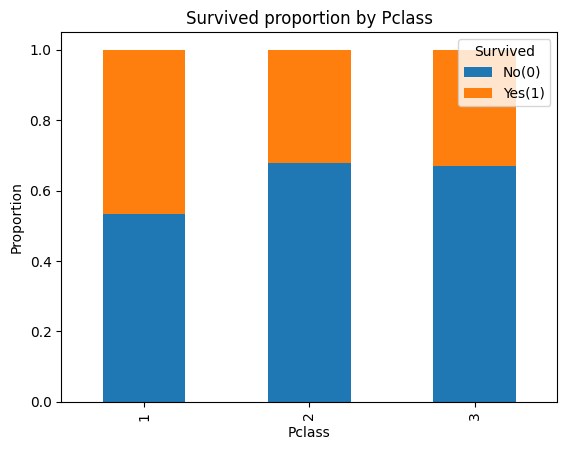

In [ ]:
prop = contingency_table.div(contingency_table.sum(axis=1), axis=0)
ax = prop.plot(kind='bar', stacked = True)
ax.set_title("Survived proportion by Pclass")
ax.set_xlabel("Pclass")
ax.set_ylabel("Proportion")
ax.legend(title = "Survived", labels = ["No(0)", "Yes(1)"]) 

- Compute the $\chi^2$ statistics of the pair Pclass and Survived variable

$E_{ij}=\frac{(row total{i}-column totsl_{j})}{N}$
$df = (r-1)(c-1) = (3-1) (2-1) = 2$
$Significance level: \alpha = 0.05$
Assumption is reliable must hold: 
- each passenger is counted once
- both variables are categorical
- all $E_{ij} >= 1$ and at least 80% of $E_{ij} >= 5$

In [34]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
expected_df = pd.DataFrame(expected, index = contingency_table.index, columns = contingency_table.columns)
print("Chi-square statistic:", chi2)
print('p_value:', p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected_df) 

alpha = 0.05 
if p_value < alpha: 
    print("Reject the Ho: they are independent")
    print("There is an association between Pclass and Survived")
else: 
    print("Fail to reject Ho: they are associated")

Chi-square statistic: 6.693869422819262
p_value: 0.03519206276590605
Degrees of freedom: 2
Expected frequencies:
 Survived           0          1
Pclass                         
1          68.090909  38.909091
2          59.181818  33.818182
3         138.727273  79.272727
Reject the Ho: they are independent
There is an association between Pclass and Survived



`Result`: the $\chi^2 $- test result shows that we can reject the null hypothesis $H_0$ of the two variables being independent at $95\%$ confidence level. And the assumptions of $\chi^2$-test are reliable.

**B. Pclass vs Embarked:**

- Perform $\chi^2$-test on this pair of variables.
- Perform CA on this pair of variables.
- Create `symmetric biplot` of the resulting CA.
- Interpret the result.

chi-aquare test -> answer Is there an association? 
CA -> answer how are categories related and structured? 

- Q: there is an association between Pclass and Embarked?
    - Ho: there is no association between Pclass and Embarked
    - H1: there is an association between Pclass and Embarked

In [38]:
df.columns

Index(['Pclass', 'Survived'], dtype='object')

In [ ]:
# To do
df= pd.read_csv(path + "/titanic.csv")

dfb = df[['Pclass', 'Embarked']].dropna()
print(dfb['Pclass'].unique())
print(dfb['Embarked'].unique())
# Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).

[3 2 1]
['Q' 'S' 'C']


In [ ]:
#  contingency table 
N = pd.crosstab(dfb['Pclass'], dfb['Embarked'])
N.index.name = "Pclass"
N.columns.name = "Embarked" 
N

Embarked,C,Q,S
Pclass,,,
1,56,1,50
2,11,4,78
3,35,41,142


In [47]:
# chi square test
chi2, p_value, dof, expected = chi2_contingency(N)
expected_df = pd.DataFrame(expected, index = N.index, columns = N.columns)
print("Chi-square statistic:", chi2)
print('p_value:', p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected_df)

alpha = 0.05
if p_value < alpha: 
    print("Reject the Ho and accept H1")
else: 
    print("Fail to reject Ho")

Chi-square statistic: 82.83186678873668
p_value: 4.373384811850251e-17
Degrees of freedom: 4
Expected frequencies:
 Embarked          C          Q           S
Pclass                                    
1         26.110048  11.775120   69.114833
2         22.693780  10.234450   60.071770
3         53.196172  23.990431  140.813397
Reject the Ho and accept H1


In [ ]:
# assumption check 
# must hold with 3 conditions:
# 1. All expected frequencies >= 1
if (expected_df >= 1).all().all():
    print("Condition 1 met: All expected frequencies >= 1")
else:
    print("Condition 1 not met")
# 2. No more than 20% of expected frequencies < 5
num_less_than_5 = (expected_df < 5).sum().sum()
total_cells = expected_df.size
percentage_less_than_5 = num_less_than_5 / total_cells * 100
if percentage_less_than_5 <= 20:
    print("Condition 2 met: No more than 20% of expected frequencies < 5")
else:
    print("Condition 2 not met")
# 3. Sample size large enough (n >= 50)
n = N.values.sum()
if n >= 50:
    print("Condition 3 met: Sample size large enough (n >= 50)")
else:
    print("Condition 3 not met")
    


Condition 1 met: All expected frequencies >= 1
Condition 2 met: No more than 20% of expected frequencies < 5
Condition 3 met: Sample size large enough (n >= 50)



CA eigenvalues (inertia) and explained inertia ratio:
  Dim 1: inertia=0.159200, ratio=0.8034
  Dim 2: inertia=0.038962, ratio=0.1966
  Dim 3: inertia=0.000000, ratio=0.0000
  Total inertia: 0.198162


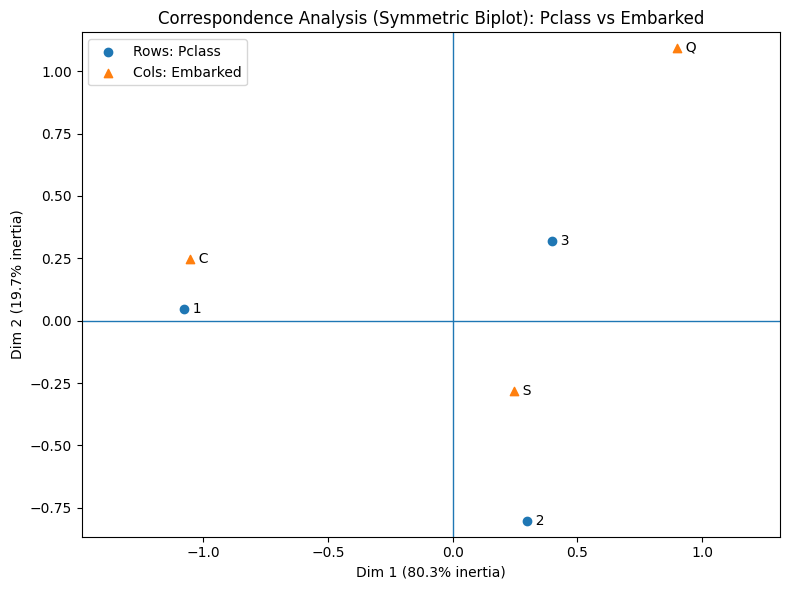

In [52]:
# 4) Correspondence Analysis (CA)
#    - CA via SVD of standardized residual matrix
#    - Symmetric map: alpha = 0.5 (rows and cols scaled equally)

N_mat = N.to_numpy(dtype=float)
n = N_mat.sum()

P = N_mat / n                           # correspondence matrix
r = P.sum(axis=1, keepdims=True)        # row masses (r x 1)
c = P.sum(axis=0, keepdims=True)        # col masses (1 x c)

# Diagonal mass matrices and their inverse square-roots
Dr_inv_sqrt = np.diag(1.0 / np.sqrt(r.ravel()))
Dc_inv_sqrt = np.diag(1.0 / np.sqrt(c.ravel()))

# Standardized residuals matrix
S = Dr_inv_sqrt @ (P - r @ c) @ Dc_inv_sqrt

# SVD
U, s, Vt = np.linalg.svd(S, full_matrices=False)  # s are singular values
V = Vt.T

# Eigenvalues (inertia per dimension)
eig = s**2
total_inertia = eig.sum()
explained = eig / total_inertia

# Choose number of dimensions to plot
k = 2  # symmetric biplot is typically 2D
U_k = U[:, :k]
V_k = V[:, :k]
s_k = s[:k]

# Symmetric principal coordinates: alpha = 0.5
# Row coords:  Dr^{-1/2} U Σ^{1/2}
# Col coords:  Dc^{-1/2} V Σ^{1/2}
Sigma_half = np.diag(np.sqrt(s_k))
F = Dr_inv_sqrt @ U_k @ Sigma_half   # row principal coords (symmetric)
G = Dc_inv_sqrt @ V_k @ Sigma_half   # col principal coords (symmetric)

row_labels = N.index.astype(str).tolist()
col_labels = N.columns.astype(str).tolist()

print("\nCA eigenvalues (inertia) and explained inertia ratio:")
for i, (ev, ratio) in enumerate(zip(eig, explained), start=1):
    print(f"  Dim {i}: inertia={ev:.6f}, ratio={ratio:.4f}")
print(f"  Total inertia: {total_inertia:.6f}")

# 5) Symmetric biplot

fig, ax = plt.subplots(figsize=(8, 6))

# Plot row points (Pclass)
ax.scatter(F[:, 0], F[:, 1], marker="o", label="Rows: Pclass")
for (x, y), lab in zip(F, row_labels):
    ax.text(x, y, f"  {lab}", va="center")

# Plot column points (Embarked)
ax.scatter(G[:, 0], G[:, 1], marker="^", label="Cols: Embarked")
for (x, y), lab in zip(G, col_labels):
    ax.text(x, y, f"  {lab}", va="center")

# Axes lines and labels
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_xlabel(f"Dim 1 ({explained[0]*100:.1f}% inertia)")
ax.set_ylabel(f"Dim 2 ({explained[1]*100:.1f}% inertia)")
ax.set_title("Correspondence Analysis (Symmetric Biplot): Pclass vs Embarked")
ax.legend()
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.show()


- Points close together are associated
    - Pclass 1 is close to C (Cherbourg) → first-class passengers mostly boarded at Cherbourg.
    - Pclass 2 is close to S (Southampton) → second-class passengers mostly boarded at Southampton.
    - Pclass 3 is close to Q (Queenstown) → third-class passengers mostly boarded at Queenstown.

- Distance from the center (origin)
    - Q and C are far from the center → they have very specific passenger types.
    - S is closer to the center → it served a mix of all classes (more average).

- Axes meaning
    - Dim 1 (80.3%) shows the main difference in boarding patterns (rich vs common passengers).
    - Dim 2 (19.7%) shows smaller, secondary differences.
    - CA1+CA2 = 99% can capture the association between Pclass and Embarked. 


- **Row distance**: Chi-square distance

In [54]:
row_distance_table = pd.DataFrame({
    "Pclass": N.index,
    "Dim1": F[:, 0],
    "Dim2": F[:, 1],
    "Distance_from_origin": np.sqrt(F[:, 0]**2 + F[:, 1]**2)
}).set_index("Pclass").sort_values(
    by="Distance_from_origin", ascending=False
)

row_distance_table.round(4)


,Dim1,Dim2,Distance_from_origin
Pclass,,,
1,-1.0748,0.0476,1.0758
2,0.2993,-0.8034,0.8574
3,0.3998,0.3194,0.5117


- Pclass 1: Very far from the origin → first-class passengers boarded at ports very different from the average (they had a distinct boarding pattern).

- Pclass 2: Medium distance → second-class passengers boarded somewhat differently, but not as strongly as first class.

- Pclass 3: Closest to the origin → third-class passengers boarded in a typical/average way, similar to most passengers.

- **Column distance** : Chi-square distance

In [55]:
column_distance_table = pd.DataFrame({
    "Embarked": N.columns,
    "Dim1": G[:, 0],
    "Dim2": G[:, 1],
    "Distance_from_origin": np.sqrt(G[:, 0]**2 + G[:, 1]**2)
}).set_index("Embarked").sort_values(
    by="Distance_from_origin", ascending=False
)

column_distance_table.round(4)


,Dim1,Dim2,Distance_from_origin
Embarked,,,
Q,0.8998,1.0935,1.4161
C,-1.0541,0.2486,1.0830
S,0.2449,-0.2802,0.3722


- Q (Queenstown): Farthest from the origin → very distinctive boarding port, strongly linked to a specific passenger class.

- C (Cherbourg): Also far from the origin → clear, non-average boarding pattern, associated mainly with higher-class passengers.

- S (Southampton): Close to the origin → average boarding port, used by passengers from all classes.

## 3. Eye and Hair color

Study the connection between eye and hair colors from the `Eye & Hair Color` dataset available in kaggle as [Hair Eye Color](https://www.kaggle.com/datasets/jasleensondhi/hair-eye-color).

In [53]:
# To do
import pandas as pd 
path = r'D:\I5_AMS\EDA\Correspondence Analysis (CA)\HairEyeColor.csv'
hair = pd.read_csv(path)

In [57]:
print(df.shape)
hair.head()

(418, 12)


,Unnamed: 0,Hair,Eye,Sex,Freq
0,1,Black,Brown,Male,32
1,2,Brown,Brown,Male,53
2,3,Red,Brown,Male,10
3,4,Blond,Brown,Male,3
4,5,Black,Blue,Male,11


In [60]:
print(hair.isnull().sum())
print(hair.duplicated().sum())

Unnamed: 0    0
Hair          0
Eye           0
Sex           0
Freq          0
dtype: int64
0


In [61]:
hair.describe()

,Unnamed: 0,Freq
count,32.000000,32.000000
mean,16.500000,18.500000
std,9.380832,18.242099
min,1.000000,2.000000
25%,8.750000,7.000000
50%,16.500000,10.000000
75%,24.250000,29.250000
max,32.000000,66.000000


1. Is there a statistical association between hair color and eye color?

Null hypothesis (H₀):
Hair color and eye color are independent

Alternative hypothesis (H₁):
Hair color and eye color are associated

In [64]:
hair.columns

Index(['Unnamed: 0', 'Hair', 'Eye', 'Sex', 'Freq'], dtype='object')

In [72]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p_value)


Chi-square statistic: 138.28984162600827
Degrees of freedom: 9
P-value: 2.3252867870988044e-25


As the p-value is very small, we reject the null hypothesis of independence.
`Chi-square test: confirms association exists`

So, we shall to explore the association between these two categorical variables.


In [95]:
import plotly.express as px
import pandas as pd

# Ensure clean column names
df.columns = df.columns.str.strip()

# Group by Hair and Eye using frequency
df_freq = (
    hair.groupby(['Hair', 'Eye'])['Freq']
      .sum()
      .reset_index()
)

# Convert to percentage within each Hair group
df_freq['percent'] = (
    df_freq.groupby('Hair')['Freq']
           .apply(lambda x: x / x.sum() * 100)
           .reset_index(level=0, drop=True)
)

# Plot
fig = px.bar(
    df_freq,
    x="Hair",
    y="percent",
    color="Eye",
    barmode="stack",
    text=df_freq['percent'].round(2).astype(str) + '%'
)

fig.update_layout(
    width=510,
    height=430,
    title='Stacked Bar Plot of Hair Color vs Eye Color',
    xaxis_title='Hair Color',
    yaxis_title='Percentage (%)',
    legend_title='Eye Color'
)

fig.update_traces(textposition='inside')
fig.show()


bivariate plot may not clearly show the association between categories of the two variables.
It only shows the distribution of hair and eye color within each workclass category.

### 0. contingency table 

In [ ]:
from scipy.stats import chi2_contingency

# contingency table 
contingency_table = pd.peivot_table(
    hair,
    values='Freq',
    index="Hair",
    columns="Eye",
    aggfunc="sum"
)

print(contingency_table)


Eye    Blue  Brown  Green  Hazel
Hair                            
Black    20     68      5     15
Blond    94      7     16     10
Brown    84    119     29     54
Red      17     26     14     14


### 1. Distance Row and Column Profile

1. hair = row profile 

    Given a hair color, what is the distribution of eye colors?

$$
r_{ij} = \frac{n_{ij}}{n_{i\cdot}}
$$


2. eye = columns profile  
    Given an eye color, how is it distributed across hair colors?
$$
c_{ij} = \frac{n_{ij}}{n_{i\cdot}}
$$


In [94]:
# Row profiles: Hair → Eye
row_profiles = contingency_table.div(contingency_table.sum(axis=1), axis=0)
row_profiles.round(3)


Eye,Blue,Brown,Green,Hazel
Hair,,,,
Black,0.185,0.630,0.046,0.139
Blond,0.740,0.055,0.126,0.079
Brown,0.294,0.416,0.101,0.189
Red,0.239,0.366,0.197,0.197


Black hair mostly brown eyes. Blond hair mostly blue eye

In [93]:
# Column profiles: Eye → Hair
col_profiles = contingency_table.div(contingency_table.sum(axis=0), axis=1)
col_profiles.round(3)


Eye,Blue,Brown,Green,Hazel
Hair,,,,
Black,0.093,0.309,0.078,0.161
Blond,0.437,0.032,0.250,0.108
Brown,0.391,0.541,0.453,0.581
Red,0.079,0.118,0.219,0.151


Brown eye mostly brown hair. Hazel eye mostly brown hair.

### 3. Use Ch-square test for interpret

- Chi-square distance for Hair (row profiles): explain where the association comes from


In [97]:
import numpy as np
from scipy.spatial.distance import pdist, squareform

def chi_squared_distance_matrix(contingency_table):
    data = np.array(contingency_table, dtype=float)
    
    # Row profiles
    row_sums = data.sum(axis=1)[:, np.newaxis]
    row_profiles = np.divide(data, row_sums, where=row_sums != 0)
    
    # Column masses
    grand_total = data.sum()
    col_masses = data.sum(axis=0) / grand_total
    
    # Weighting
    weights = 1.0 / np.sqrt(col_masses)
    transformed_data = row_profiles * weights
    
    # Euclidean distances
    distances = pdist(transformed_data, metric='euclidean')
    dist_matrix = squareform(distances)
    
    return pd.DataFrame(
        dist_matrix,
        index=contingency_table.index,
        columns=contingency_table.index
    )


In [ ]:
# Hair distance - row
hair_dist = chi_squared_distance_matrix(contingency_table)
hair_dist.round(3)

Hair,Black,Blond,Brown,Red
Hair,,,,
Black,0.000,1.348,0.446,0.654
Blond,1.348,0.000,0.991,1.043
Brown,0.446,0.991,0.000,0.316
Red,0.654,1.043,0.316,0.000


Chai-square distance interpret: 
- d(i,i') = small => have very similar eye-color distribution. 
- d(i,i') = large => have very different eye-color patterns. 

Row profiles: Brown and Red are the most similar row profiles.
- Brown vs Red = 0.31 They contribute similarly to the Hair–Eye association. 

- Black vs Blond = 1.34 Strongly different eye-color distributions. 

In [100]:
# Eye distance - column
eye_dist = chi_squared_distance_matrix(contingency_table.T)
eye_dist.round(3)


Eye,Blue,Brown,Green,Hazel
Eye,,,,
Blue,0.000,1.040,0.579,0.806
Brown,1.040,0.000,0.784,0.398
Green,0.579,0.784,0.000,0.453
Hazel,0.806,0.398,0.453,0.000


- Small > similar hair compositions
- Large > structurally different eye groups

+ Closest pairs
    - Brown – Hazel (0.398)
    - Green – Hazel (0.453)
    - Blue – Green (0.579)
+ Most different
    - Blue – Brown (1.040)

Column profile distances show that blue and brown eyes have the most distinct hair-color distributions, while hazel and green eyes act as intermediate categories, indicating strong structural association between eye and hair color.

### 4. GSVD & Correspondence Analysis (CA)

In [ ]:
import numpy as np
import pandas as pd

# Step 1: Contingency table
N = contingency_table.values
n = N.sum()
P = N / n
# Step 2: Masses
r = P.sum(axis=1)
c = P.sum(axis=0)

Dr_inv_sqrt = np.diag(1 / np.sqrt(r))
Dc_inv_sqrt = np.diag(1 / np.sqrt(c))

# Step 3: Centered matrix
S = Dr_inv_sqrt @ (P - np.outer(r, c)) @ Dc_inv_sqrt

# Step 4: GSVD (via SVD)
U, s, VT = np.linalg.svd(S, full_matrices=False)

# Step 5: Coordinates 
F = Dr_inv_sqrt @ U @ np.diag(s)   # Row coords (Hair)
G = Dc_inv_sqrt @ VT.T @ np.diag(s)  # Column coords (Eye)

F = pd.DataFrame(F[:, :2], index=contingency_table.index, columns=['Dim1', 'Dim2'])
G = pd.DataFrame(G[:, :2], index=contingency_table.columns, columns=['Dim1', 'Dim2'])


In [111]:
print(F)

[[-5.04562430e-01 -2.14820455e-01  5.55090896e-02  1.55998814e-17]
 [ 8.35347769e-01 -6.95793368e-02  1.62147063e-02  1.55998814e-17]
 [-1.48252702e-01  3.26663455e-02 -4.88041352e-02  1.55998814e-17]
 [-1.29523262e-01  3.19642396e-01  8.31511732e-02  1.55998814e-17]]


- Variance explained & variance ratio

In [103]:
# Eigenvalues (inertia per dimension)
eigenvalues = s**2

# Variance explained ratio
explained_ratio = eigenvalues / eigenvalues.sum()

inertia_df = pd.DataFrame({
    'Eigenvalue (Inertia)': eigenvalues,
    'Explained Ratio': explained_ratio,
    'Cumulative Ratio': explained_ratio.cumsum()
})

inertia_df


,Eigenvalue (Inertia),Explained Ratio,Cumulative Ratio
0,2.087727e-01,8.937273e-01,0.893727
1,2.222661e-02,9.514911e-02,0.988876
2,2.598439e-03,1.112356e-02,1.000000
3,2.433563e-34,1.041775e-33,1.000000


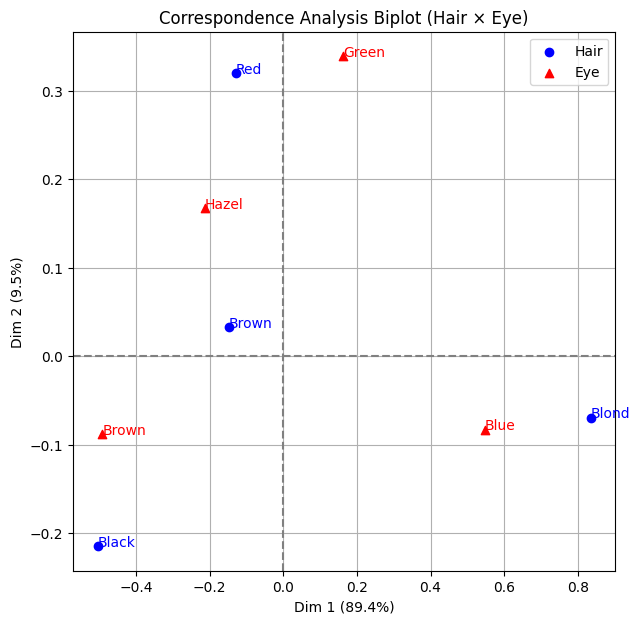

In [105]:
F2 = F[['Dim1', 'Dim2']]  # Hair
G2 = G[['Dim1', 'Dim2']]  # Eye

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Plot Hair (rows)
plt.scatter(F2['Dim1'], F2['Dim2'], color='blue', label='Hair')
for i in F2.index:
    plt.text(F2.loc[i, 'Dim1'], F2.loc[i, 'Dim2'], i, color='blue')

# Plot Eye (columns)
plt.scatter(G2['Dim1'], G2['Dim2'], color='red', marker='^', label='Eye')
for j in G2.index:
    plt.text(G2.loc[j, 'Dim1'], G2.loc[j, 'Dim2'], j, color='red')

# Axes
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')

plt.xlabel(f'Dim 1 ({explained_ratio[0]*100:.1f}%)')
plt.ylabel(f'Dim 2 ({explained_ratio[1]*100:.1f}%)')
plt.title('Correspondence Analysis Biplot (Hair × Eye)')
plt.legend()
plt.grid(True)

plt.show()



- (0,0) = no special association

- First Dim: 
    - Strong association between blond hair and blue eyes. 
    - Brown eyes occur more often with black/brown hair than expected under independence  
- Second Dim: 
    - Red hair is associated with green/hazel eyes
    - Reinforces the dark-hair/dark-eye association

- For Distance: 
    - Blond, Blue, Black, Red: far from origin => strong contributors to association

## 4. Countries and languages

Reproduce results of the association between countries and primary language spoken within those countries conducted [here](https://pmc.ncbi.nlm.nih.gov/articles/PMC3718710/). The contingency table of country of residence and primary language spoken is given below:
	
| Country\ Language  | English | French | Spanish | German | Italian | Total |
|:-------------------|:-------:|:------:|:-------:|:------:|:-------:|:-----:|
| Canada | 688 | 280 | 10 | 11 | 11 | 1000 |
| USA | 730 | 31 | 190 | 8 | 41 | 1000 |
| England | 798 | 74 | 38 | 31 | 59 | 1000 |
| Italy | 17 | 13 | 11 | 15 | 944 | 1000 |
| Switzerland | 15 | 222 | 20 | 648 | 95 | 1000 |
| Total | 2248 | 620 | 269 | 713 | 1150 | 5000 |

- Row = Country 
- Column = Language 
- Value = Counts
    Is the distribution of languages the same across all countries? 

Test: $\chi^2$-test on this dataset. (to confirms association exists)
- Ho: = Country and Language are independent 
- H1: = Country and Language are associated 

In [3]:
import pandas as pd 

df = pd.DataFrame(
    [[688,280,10,11,11],
     [730,31,190,8,41],
     [798,74,38,31,59],
     [17,13,11,15,944],
     [15,222,20,648,95]], 

    index=["Canada","USA","England","Italy","Switzerland"],
    columns=["English","French","Spanish","German","Italian"]
)
df

,English,French,Spanish,German,Italian
Canada,688,280,10,11,11
USA,730,31,190,8,41
England,798,74,38,31,59
Italy,17,13,11,15,944
Switzerland,15,222,20,648,95


In [4]:
from scipy.stats import chi2_contingency 

chi2, p_value, dof, expected = chi2_contingency(df)
print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p_value)

Chi-square statistic: 7338.935598897499
Degrees of freedom: 16
P-value: 0.0


p_value < 0.05 => reject Ho => association exists between Country and Language. (p-value is very small => strong evidence of association) 

In [ ]:
# Inspect expected frequencies 

expected_df = pd.DataFrame(
    expected,
    index = df.index,
    columns= df.columns
)
expected_df   # ? 

,English,French,Spanish,German,Italian
Canada,449.6,124.0,53.8,142.6,230.0
USA,449.6,124.0,53.8,142.6,230.0
England,449.6,124.0,53.8,142.6,230.0
Italy,449.6,124.0,53.8,142.6,230.0
Switzerland,449.6,124.0,53.8,142.6,230.0


In [6]:
import numpy as np

residuals = (df - expected_df) / np.sqrt(expected_df)
residuals.round(2)


,English,French,Spanish,German,Italian
Canada,11.24,14.01,-5.97,-11.02,-14.44
USA,13.22,-8.35,18.57,-11.27,-12.46
England,16.43,-4.49,-2.15,-9.35,-11.28
Italy,-20.40,-9.97,-5.84,-10.69,47.08
Switzerland,-20.50,8.80,-4.61,42.32,-8.90


- Row profile: Language/Country

      r = Oij/Oij

In [10]:
row_profiles = df.div(df.sum(axis=1), axis=0)
row_profiles


,English,French,Spanish,German,Italian
Canada,0.688,0.280,0.010,0.011,0.011
USA,0.730,0.031,0.190,0.008,0.041
England,0.798,0.074,0.038,0.031,0.059
Italy,0.017,0.013,0.011,0.015,0.944
Switzerland,0.015,0.222,0.020,0.648,0.095


Canada mostly English and french speakers. 
USA mostly English speakers. 
England mostly English speakers.
Italy mostly Italian speakers.
Switzerland mostly German speakers.

- Column Profile : Country/Language
   c = Oij/Oij 

In [15]:
col_profiles = df.div(df.sum(axis=0), axis=1)
col_profiles


,English,French,Spanish,German,Italian
Canada,0.306050,0.451613,0.037175,0.015428,0.009565
USA,0.324733,0.050000,0.706320,0.011220,0.035652
England,0.354982,0.119355,0.141264,0.043478,0.051304
Italy,0.007562,0.020968,0.040892,0.021038,0.820870
Switzerland,0.006673,0.358065,0.074349,0.908836,0.082609


Mostly English speakers are from USA, Canada, and England.
Mostly French speakers are from Canada and Switzerland.
Mostly Spanish speakers live in USA.
Mostly German speakers live in Switzerland.
Mostly Italian speakers live in Italy.

- χ² distances between row profiles (countries)

    Look for smallest off-diagonal values.

In [13]:
# Row and column masses
from scipy.spatial.distance import pdist, squareform

row_masses = df.sum(axis=1) / n
col_masses = df.sum(axis=0) / n

def chi2_row_distance(X, col_masses):
    W = np.diag(1 / col_masses)
    return squareform(pdist(X.values, metric="euclidean", w=W))

row_chi2 = pd.DataFrame(
    squareform(
        pdist(row_profiles.values,
              metric=lambda u, v: np.sqrt(((u - v)**2 / col_masses.values).sum()))
    ),
    index=row_profiles.index,
    columns=row_profiles.index
)

row_chi2.round(3)


,Canada,USA,England,Italy,Switzerland
Canada,0.000,1.054,0.630,2.315,1.978
USA,1.054,0.000,0.678,2.297,2.203
England,0.630,0.678,0.000,2.193,2.055
Italy,2.315,2.297,2.193,0.000,2.509
Switzerland,1.978,2.203,2.055,2.509,0.000


- Canada and England = 0.63 very similar language.
- USA and England = 0.678 very similar language. 
- Italy and Canada = 2.31 different language distribution.
 
 - Canada, USA, England from a cluster of English domainated countries. 

In [16]:
col_chi2 = pd.DataFrame(
    squareform(
        pdist(col_profiles.T.values,
              metric=lambda u, v: np.sqrt(((u - v)**2 / row_masses.values).sum()))
    ),
    index=col_profiles.columns,
    columns=col_profiles.columns
)

col_chi2.round(3)


,English,French,Spanish,German,Italian
English,0.000,1.174,1.160,2.339,2.157
French,1.174,0.000,1.849,1.583,2.140
Spanish,1.160,1.849,0.000,2.439,2.310
German,2.339,1.583,2.439,0.000,2.572
Italian,2.157,2.140,2.310,2.572,0.000


- English – Spanish 1.16 most similar language. 
- English – French 1.17 very similar language. 
- French – German 1.58 moderately similar language. 

### Apply CA : 
After we know association exites, so what is the structure of the asscciation?

In [ ]:

# s = singular values from SVD (1D array)
eigenvalues = s**2

explained_variance = pd.DataFrame({
    "Explained variance": eigenvalues,
    "Explained variance ratio": eigenvalues / eigenvalues.sum(),
    "Cumulative explained variance ratio": np.cumsum(eigenvalues) / eigenvalues.sum()
}, index=range(1, len(eigenvalues) + 1))

explained_variance.round(3).T

,1,2,3,4,5
Explained variance,0.743,0.602,0.104,0.019,0.0
Explained variance ratio,0.506,0.410,0.071,0.013,0.0
Cumulative explained variance ratio,0.506,0.916,0.987,1.000,1.0


Explained variance ratio = % of total association. 
FIrst 2 dimentions explain PC1 + PC2 = 91.6% 

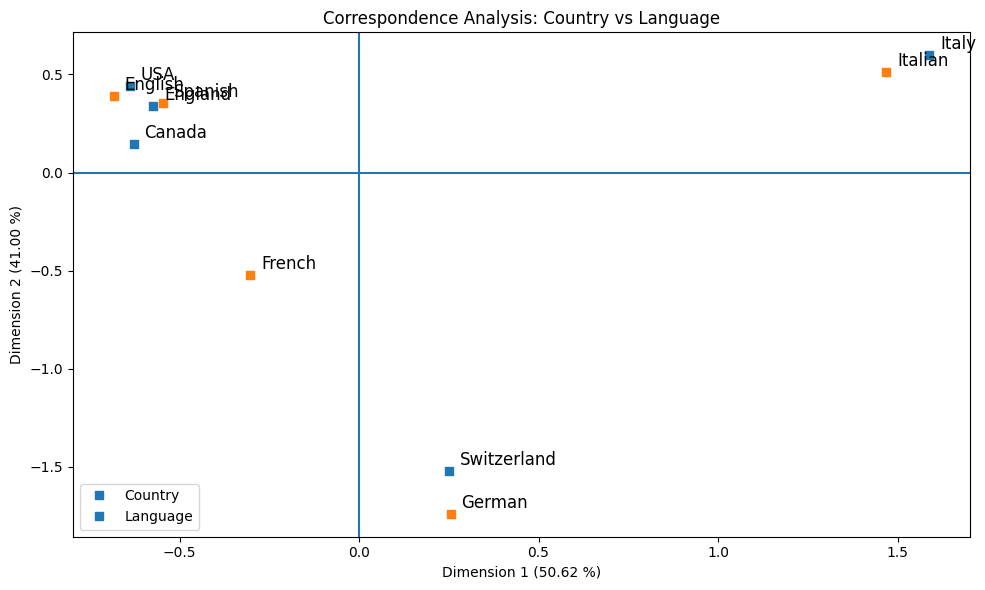

In [ ]:
#  Correspondence Analysis (CA)

N = df.values.astype(float)
n = N.sum()

P = N / n                           # correspondence matrix
r = P.sum(axis=1, keepdims=True)    # row masses
c = P.sum(axis=0, keepdims=True)    # col masses

Dr_inv_sqrt = np.diagflat(1 / np.sqrt(r))          # D_r^{-1/2}
Dc_inv_sqrt = np.diagflat(1 / np.sqrt(c)).T       # D_c^{-1/2}

# standardized residual matrix
Z = Dr_inv_sqrt @ (P - r @ c) @ Dc_inv_sqrt

# SVD
U, s, VT = np.linalg.svd(Z, full_matrices=False)

# Eigenvalues and explained inertia
eigvals = s**2
explained = eigvals / eigvals.sum() * 100

dim1_pct = explained[0]
dim2_pct = explained[1]

# Principal coordinates (symmetric map)
# Row principal coords:  F = D_r^{-1/2} U Σ
# Col principal coords:  G = D_c^{-1/2} V Σ
Sigma = np.diag(s)
F = Dr_inv_sqrt @ U @ Sigma          # countries coords
G = Dc_inv_sqrt @ VT.T @ Sigma       # languages coords

# Take first 2 dimensions
F2 = F[:, :2]
G2 = G[:, :2]

countries = df.index.tolist()
languages = df.columns.tolist()

# Plot (like the example figure)

plt.figure(figsize=(10, 6))

# Countries (blue squares)
plt.scatter(F2[:, 0], F2[:, 1], marker="s")
for i, name in enumerate(countries):
    plt.text(F2[i, 0] + 0.03, F2[i, 1] + 0.03, name, fontsize=12)

# Languages (red squares)
plt.scatter(G2[:, 0], G2[:, 1], marker="s")
for j, name in enumerate(languages):
    plt.text(G2[j, 0] + 0.03, G2[j, 1] + 0.03, name, fontsize=12)

# Axes crossing at origin
plt.axhline(0)
plt.axvline(0)

# Labels with inertia %
plt.xlabel(f"Dimension 1 ({dim1_pct:.2f} %)")
plt.ylabel(f"Dimension 2 ({dim2_pct:.2f} %)")

plt.title("Correspondence Analysis: Country vs Language")

# Create legend with colored proxy artists (to match your figure)
from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], marker='s', linestyle='None', label='Country'),
    Line2D([0], [0], marker='s', linestyle='None', label='Language')
]
plt.legend(handles=legend_items, loc="lower left", frameon=True)

plt.grid(False)
plt.tight_layout()
plt.show()


- Near the origin: 
    Points close to the origin (e.g., Canada, French) represent average profiles and show weak deviation from independence.

- Axis 1 (50.62%): 
    Separates Italy–Italian (strongly monolingual) from English-dominant countries (USA, England, Canada).

- Axis 2 (41.00%): 
    Contrasts Switzerland–German with Anglo-American countries and languages.

- Clusters: 
    USA–England–English–Spanish form one cluster, Italy–Italian another, and Switzerland–German a third.

- Deviation from origin: 
    Points far from the origin (Italy, Italian, Switzerland, German) indicate strong and distinctive associations.

Yeee 😭

# Further Readings

- [Correspondence Analysis, Hervé Abdi & Michel Béra](https://cedric.cnam.fr/fichiers/art_3066.pdf)
- [Correspondence analysis is a useful tool to uncover the relationships among categorical variables](https://pmc.ncbi.nlm.nih.gov/articles/PMC3718710/)
- [The Use of Correspondence Analysis in the Exploration of Health Survey Data](www.fbbva.es/wp-content/uploads/2017/05/dat/DT_2002_05.pdf)
- [Correspondence Analysis](https://link.springer.com/referenceworkentry/10.1007/978-1-4939-7131-2_140)